# Contrastive Learning: Learning Representations Without Labels

## 1. Introduction

**Contrastive learning** is a powerful self-supervised learning paradigm that learns meaningful representations by contrasting similar (positive) and dissimilar (negative) examples.

### What we'll learn:
- How contrastive learning works and why it's revolutionary
- The concept of positive and negative pairs
- InfoNCE loss and the temperature parameter
- Data augmentation strategies for contrastive learning
- Building a SimCLR-style model from scratch

### Why it matters:
- **Self-supervised**: Learn without labels (labels are expensive!)
- **Powerful representations**: Used in CLIP, MoCo, SimCLR
- **Transfer learning**: Pre-train on unlabeled data, fine-tune on small labeled datasets
- **Foundation for modern AI**: Powers models like CLIP (vision-language), BERT alternatives

### Core intuition:
"Similar things should have similar representations, different things should have different representations."

We'll build this understanding from first principles!

## 2. Setup

In [1]:
# Standard imports
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, Dataset
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

# Shared library
from aiml_notebooks import (
    get_device, 
    set_seed, 
    count_parameters,
    create_dataset,
    TrainingHistory,
    CIFAR10_MEAN,
    CIFAR10_STD,
)

%load_ext autoreload
%autoreload 2

### Set random seed for reproducibility

In [2]:
set_seed(42)

### Configure device

In [3]:
device = get_device()
print(f"Using device: {device}")

Using MPS (Metal Performance Shaders) for GPU acceleration
Using device: mps


## 3. The Core Idea: Positive and Negative Pairs

### What are positive and negative pairs?

In contrastive learning, we create pairs of examples:
- **Positive pairs**: Different views of the same image (e.g., two augmented versions)
- **Negative pairs**: Views from different images

The goal: **Maximize similarity between positives, minimize similarity between negatives.**

Let's start with a simple embedding space visualization.

### Visualizing the concept with random embeddings

Imagine we have 5 images, each with 2 augmented views. Let's see what happens when we represent them in 2D space.

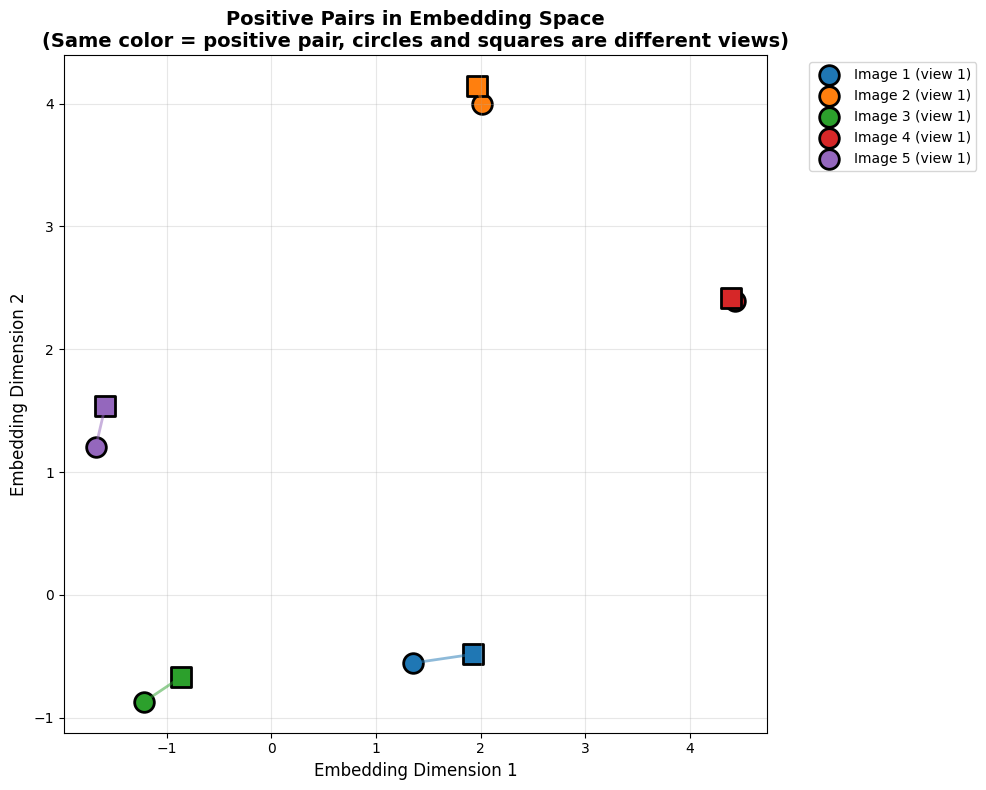

In [4]:
# Simulate 5 images with 2 views each in 2D embedding space
np.random.seed(42)
n_images = 5

# Create cluster centers (one per image)
centers = np.random.randn(n_images, 2) * 3

# Create two views per image (with small noise)
view1 = centers + np.random.randn(n_images, 2) * 0.3
view2 = centers + np.random.randn(n_images, 2) * 0.3

# Visualize
plt.figure(figsize=(10, 8))
colors = plt.cm.tab10(np.arange(n_images))

for i in range(n_images):
    plt.scatter(view1[i, 0], view1[i, 1], c=[colors[i]], marker='o', s=200, 
                label=f'Image {i+1} (view 1)', edgecolors='black', linewidth=2)
    plt.scatter(view2[i, 0], view2[i, 1], c=[colors[i]], marker='s', s=200, 
                edgecolors='black', linewidth=2)
    # Draw line connecting positive pairs
    plt.plot([view1[i, 0], view2[i, 0]], [view1[i, 1], view2[i, 1]], 
             c=colors[i], linewidth=2, alpha=0.5)

plt.xlabel('Embedding Dimension 1', fontsize=12)
plt.ylabel('Embedding Dimension 2', fontsize=12)
plt.title('Positive Pairs in Embedding Space\n(Same color = positive pair, circles and squares are different views)', 
          fontsize=14, fontweight='bold')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Key insight:

**Positive pairs** (same color, connected by line) should be **close together** in embedding space.

**Negative pairs** (different colors) should be **far apart**.

This is the fundamental principle of contrastive learning!

## 4. Measuring Similarity: Cosine Similarity

Before we can pull positives together and push negatives apart, we need to **measure similarity**.

**Cosine similarity** is the standard choice:

$$\text{sim}(\mathbf{u}, \mathbf{v}) = \frac{\mathbf{u} \cdot \mathbf{v}}{\|\mathbf{u}\| \|\mathbf{v}\|}$$

- Range: $[-1, 1]$
- $1$ = identical direction (very similar)
- $0$ = orthogonal (unrelated)
- $-1$ = opposite direction (very dissimilar)

### Let's compute cosine similarity for some examples

In [5]:
def cosine_similarity(x, y):
    """Compute cosine similarity between two vectors."""
    return F.cosine_similarity(x, y, dim=-1)

# Example vectors
v1 = torch.tensor([1.0, 0.0, 0.0])
v2 = torch.tensor([0.9, 0.1, 0.0])  # Similar to v1
v3 = torch.tensor([0.0, 1.0, 0.0])  # Orthogonal to v1
v4 = torch.tensor([-1.0, 0.0, 0.0])  # Opposite to v1

print("Cosine similarities:")
print(f"v1 ↔ v2 (similar):     {cosine_similarity(v1, v2).item():.3f}")
print(f"v1 ↔ v3 (orthogonal):  {cosine_similarity(v1, v3).item():.3f}")
print(f"v1 ↔ v4 (opposite):    {cosine_similarity(v1, v4).item():.3f}")

Cosine similarities:
v1 ↔ v2 (similar):     0.994
v1 ↔ v3 (orthogonal):  0.000
v1 ↔ v4 (opposite):    -1.000


### Batched cosine similarity

In practice, we need to compute similarity between all pairs in a batch efficiently.

In [6]:
def compute_similarity_matrix(z):
    """
    Compute pairwise cosine similarity matrix.
    
    Args:
        z: Tensor of shape (batch_size, embedding_dim)
    
    Returns:
        Similarity matrix of shape (batch_size, batch_size)
    """
    # Normalize to unit vectors
    z_norm = F.normalize(z, dim=1)
    
    # Compute similarity matrix (matrix multiplication)
    similarity = torch.mm(z_norm, z_norm.t())
    
    return similarity

# Example: 4 embeddings in 3D space
embeddings = torch.tensor([
    [1.0, 0.0, 0.0],
    [0.9, 0.1, 0.0],
    [0.0, 1.0, 0.0],
    [-1.0, 0.0, 0.0],
])

sim_matrix = compute_similarity_matrix(embeddings)
print("Similarity matrix:")
print(sim_matrix.numpy())
print("\nNote: Diagonal is 1.0 (each vector is identical to itself)")

Similarity matrix:
[[ 1.          0.9938837   0.         -1.        ]
 [ 0.9938837   1.          0.11043153 -0.9938837 ]
 [ 0.          0.11043153  1.          0.        ]
 [-1.         -0.9938837   0.          1.        ]]

Note: Diagonal is 1.0 (each vector is identical to itself)


## 5. The Contrastive Loss: InfoNCE

Now we know how to measure similarity. How do we turn this into a loss function?

Enter **InfoNCE** (Information Noise-Contrastive Estimation), the heart of contrastive learning.

### The intuition:

For each anchor embedding $\mathbf{z}_i$:
1. We have **1 positive** example (its augmented pair) $\mathbf{z}_i^+$
2. We have **N-1 negatives** (all other examples in the batch)

The loss asks: **"Can you identify the positive among all the negatives?"**

### The formula:

$$\mathcal{L}_i = -\log \frac{\exp(\text{sim}(\mathbf{z}_i, \mathbf{z}_i^+) / \tau)}{\sum_{k=1}^{2N} \mathbb{1}_{[k \neq i]} \exp(\text{sim}(\mathbf{z}_i, \mathbf{z}_k) / \tau)}$$

Where:
- $\tau$ is the **temperature parameter** (controls how "hard" the task is)
- $\mathbb{1}_{[k \neq i]}$ excludes the anchor itself
- We sum over all $2N$ examples (each image has 2 views)

This is essentially a **cross-entropy loss** where the positive is the "correct class"!

### Implementing InfoNCE loss

In [7]:
def info_nce_loss(z_i, z_j, temperature=0.5):
    """
    InfoNCE loss for contrastive learning.
    
    Args:
        z_i: Embeddings for view 1, shape (batch_size, embedding_dim)
        z_j: Embeddings for view 2, shape (batch_size, embedding_dim)
        temperature: Temperature parameter τ
    
    Returns:
        Loss value
    """
    batch_size = z_i.shape[0]
    
    # Concatenate both views
    z = torch.cat([z_i, z_j], dim=0)  # Shape: (2 * batch_size, embedding_dim)
    
    # Compute similarity matrix
    similarity = compute_similarity_matrix(z)  # Shape: (2N, 2N)
    
    # Apply temperature
    similarity = similarity / temperature
    
    # Create mask to identify positive pairs
    # For view 1: positives are in the second half (shifted by batch_size)
    # For view 2: positives are in the first half
    mask = torch.zeros((2 * batch_size, 2 * batch_size), dtype=torch.bool, device=z.device)
    for i in range(batch_size):
        mask[i, batch_size + i] = True  # View 1 → View 2
        mask[batch_size + i, i] = True  # View 2 → View 1
    
    # Mask out self-similarity (diagonal)
    self_mask = torch.eye(2 * batch_size, dtype=torch.bool, device=z.device)
    
    # Compute log probabilities
    # For each row: positive is the masked element, negatives are all others (except self)
    positives = similarity[mask].view(2 * batch_size, 1)
    
    # For negatives: exclude self and positive
    negatives_mask = ~(mask | self_mask)
    
    # Compute logsumexp over all similarities (positive + negatives)
    # We use the log-sum-exp trick for numerical stability
    exp_sim = torch.exp(similarity)
    exp_sim = exp_sim * (~self_mask).float()  # Exclude self
    
    denominator = exp_sim.sum(dim=1, keepdim=True)
    
    # Log probability of positive
    log_prob = positives - torch.log(denominator)
    
    # Loss is negative log probability
    loss = -log_prob.mean()
    
    return loss

# Test with dummy data
batch_size = 4
embedding_dim = 8

# Create dummy embeddings
z1 = torch.randn(batch_size, embedding_dim)
z2 = torch.randn(batch_size, embedding_dim)

loss = info_nce_loss(z1, z2, temperature=0.5)
print(f"InfoNCE loss: {loss.item():.4f}")
print("\n(Loss is high because embeddings are random - not yet learned!)")

InfoNCE loss: 2.2619

(Loss is high because embeddings are random - not yet learned!)


### Let's see what happens with learned embeddings

Create positives that are actually similar and negatives that are dissimilar.

In [8]:
# Create positives: add small noise to create "augmented" views
z1_good = torch.randn(batch_size, embedding_dim)
z2_good = z1_good + torch.randn(batch_size, embedding_dim) * 0.1  # Similar to z1

loss_good = info_nce_loss(z1_good, z2_good, temperature=0.5)

print("Comparison:")
print(f"Random embeddings loss:  {loss.item():.4f}")
print(f"Similar positives loss:  {loss_good.item():.4f}")
print(f"\nImprovement: {(loss.item() - loss_good.item()) / loss.item() * 100:.1f}%")
print("\n✓ When positives are similar, the loss is lower!")

Comparison:
Random embeddings loss:  2.2619
Similar positives loss:  0.4988

Improvement: 77.9%

✓ When positives are similar, the loss is lower!


## 6. The Temperature Parameter τ

The **temperature** parameter controls the "hardness" of the classification:

- **Low temperature** (e.g., 0.1): Makes the softmax "harder" → model must be very confident
- **High temperature** (e.g., 1.0): Makes the softmax "softer" → model can be less confident

### Intuition:
Think of it like exam difficulty:
- Low τ = Hard exam (need high confidence to pass)
- High τ = Easy exam (lower confidence OK)

Let's visualize this!

### Visualizing temperature effect on softmax

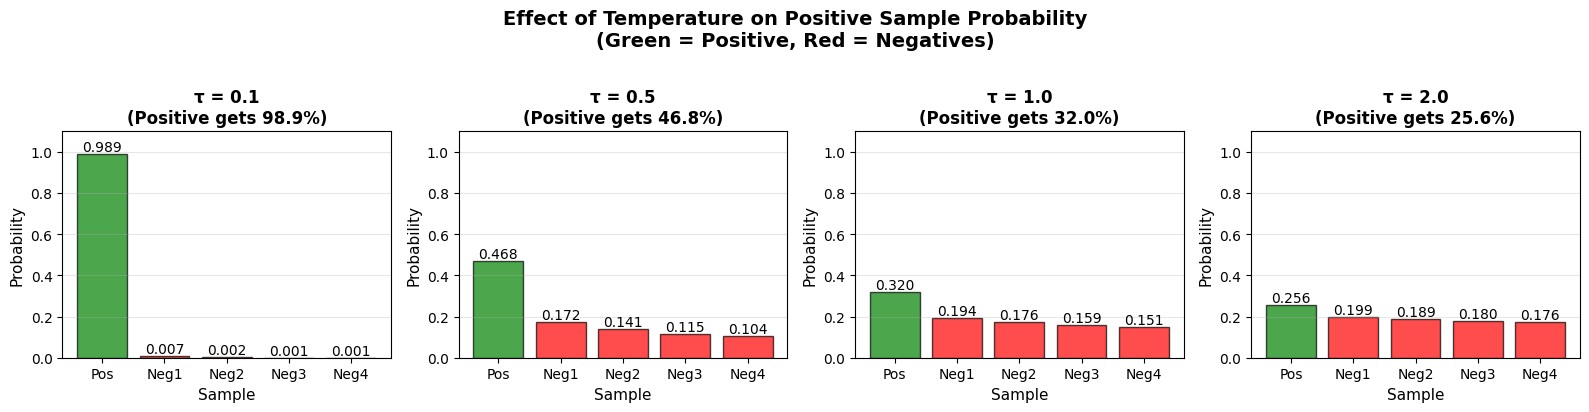

Key observations:
• Low τ (0.1): Positive gets ~99% probability → very confident
• High τ (2.0): Positive gets ~30% probability → less confident
• Typical choice: τ = 0.5 (balanced)


In [9]:
# Simulate similarity scores: positive is highest, negatives are lower
similarities = torch.tensor([0.8, 0.3, 0.2, 0.1, 0.05])  # First is positive

temperatures = [0.1, 0.5, 1.0, 2.0]

fig, axes = plt.subplots(1, 4, figsize=(16, 4))

for idx, tau in enumerate(temperatures):
    # Apply temperature scaling and softmax
    probs = F.softmax(similarities / tau, dim=0)
    
    # Plot
    ax = axes[idx]
    colors = ['green' if i == 0 else 'red' for i in range(len(similarities))]
    bars = ax.bar(range(len(similarities)), probs.numpy(), color=colors, alpha=0.7, edgecolor='black')
    
    # Add value labels on bars
    for i, (bar, prob) in enumerate(zip(bars, probs)):
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{prob:.3f}',
                ha='center', va='bottom', fontsize=10)
    
    ax.set_xlabel('Sample', fontsize=11)
    ax.set_ylabel('Probability', fontsize=11)
    ax.set_title(f'τ = {tau}\n(Positive gets {probs[0]:.1%})', fontsize=12, fontweight='bold')
    ax.set_ylim([0, 1.1])
    ax.grid(True, alpha=0.3, axis='y')
    ax.set_xticks(range(len(similarities)))
    ax.set_xticklabels(['Pos'] + [f'Neg{i}' for i in range(1, len(similarities))])

plt.suptitle('Effect of Temperature on Positive Sample Probability\n(Green = Positive, Red = Negatives)', 
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("Key observations:")
print("• Low τ (0.1): Positive gets ~99% probability → very confident")
print("• High τ (2.0): Positive gets ~30% probability → less confident")
print("• Typical choice: τ = 0.5 (balanced)")

### How temperature affects the loss

Let's see how different temperatures affect the actual loss value.

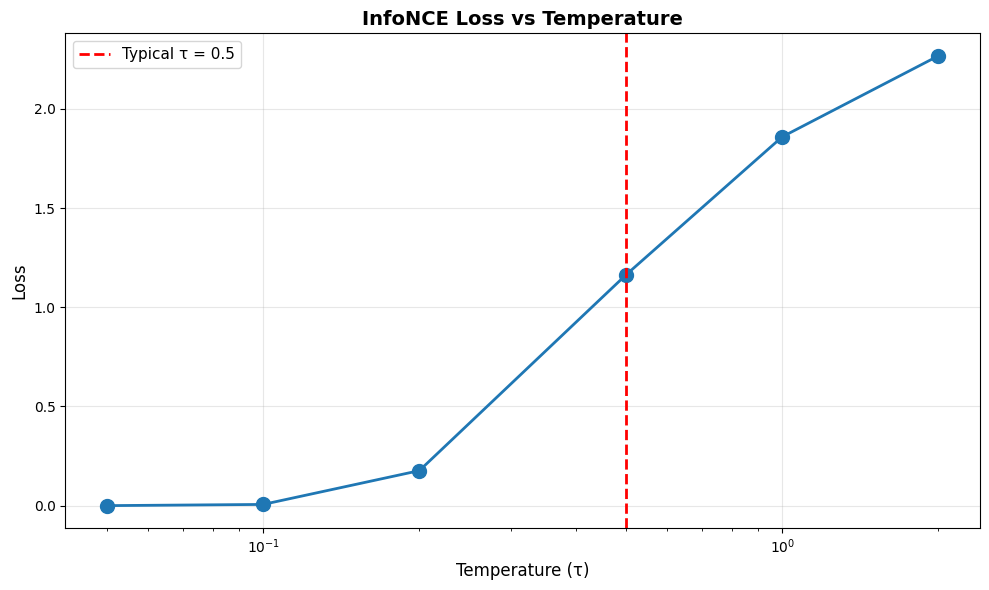

Temperature is a crucial hyperparameter!
• Too low: gradients might vanish
• Too high: task becomes too easy, learns poor representations
• Sweet spot: Usually between 0.1 and 0.5


In [10]:
# Create embeddings with varying similarity to positive
z1_test = torch.randn(8, 16)
z2_test = z1_test + torch.randn(8, 16) * 0.2

temperatures = [0.05, 0.1, 0.2, 0.5, 1.0, 2.0]
losses = []

for tau in temperatures:
    loss = info_nce_loss(z1_test, z2_test, temperature=tau)
    losses.append(loss.item())

plt.figure(figsize=(10, 6))
plt.plot(temperatures, losses, marker='o', linewidth=2, markersize=10)
plt.xlabel('Temperature (τ)', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.title('InfoNCE Loss vs Temperature', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.xscale('log')

# Mark typical value
plt.axvline(x=0.5, color='red', linestyle='--', label='Typical τ = 0.5', linewidth=2)
plt.legend(fontsize=11)

plt.tight_layout()
plt.show()

print("Temperature is a crucial hyperparameter!")
print("• Too low: gradients might vanish")
print("• Too high: task becomes too easy, learns poor representations")
print("• Sweet spot: Usually between 0.1 and 0.5")

## 7. Data Augmentation for Contrastive Learning

**Data augmentation** is CRITICAL for contrastive learning. Why?

We need to create two different **views** of the same image that:
1. Look different enough to be interesting
2. Preserve the semantic content (so they're truly positive pairs)

### SimCLR augmentations:
- Random crop and resize
- Random horizontal flip
- Color jittering (brightness, contrast, saturation, hue)
- Random grayscale
- Gaussian blur (optional)

The **composition** matters - SimCLR found that crop + color jitter are most important!

### Defining augmentation pipeline

In [11]:
def get_simclr_augmentation(size=32, s=0.5):
    """
    Get SimCLR-style augmentation pipeline.
    
    Args:
        size: Image size
        s: Strength of color jitter
    """
    color_jitter = transforms.ColorJitter(
        brightness=0.8 * s,
        contrast=0.8 * s,
        saturation=0.8 * s,
        hue=0.2 * s
    )
    
    augmentation = transforms.Compose([
        transforms.RandomResizedCrop(size=size, scale=(0.2, 1.0)),
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.RandomApply([color_jitter], p=0.8),
        transforms.RandomGrayscale(p=0.2),
        transforms.ToTensor(),
        transforms.Normalize(mean=CIFAR10_MEAN, std=CIFAR10_STD),
    ])
    
    return augmentation

print("✓ Augmentation pipeline defined")
print("\nKey augmentations:")
print("1. Random crop (forces model to recognize objects at different scales)")
print("2. Color jitter (forces model to be color-invariant)")
print("3. Grayscale (80% chance to keep color, 20% to remove)")
print("4. Horizontal flip (simple but effective)")

✓ Augmentation pipeline defined

Key augmentations:
1. Random crop (forces model to recognize objects at different scales)
2. Color jitter (forces model to be color-invariant)
3. Grayscale (80% chance to keep color, 20% to remove)
4. Horizontal flip (simple but effective)


### Visualizing augmentations

Let's see what two augmented views of the same image look like.

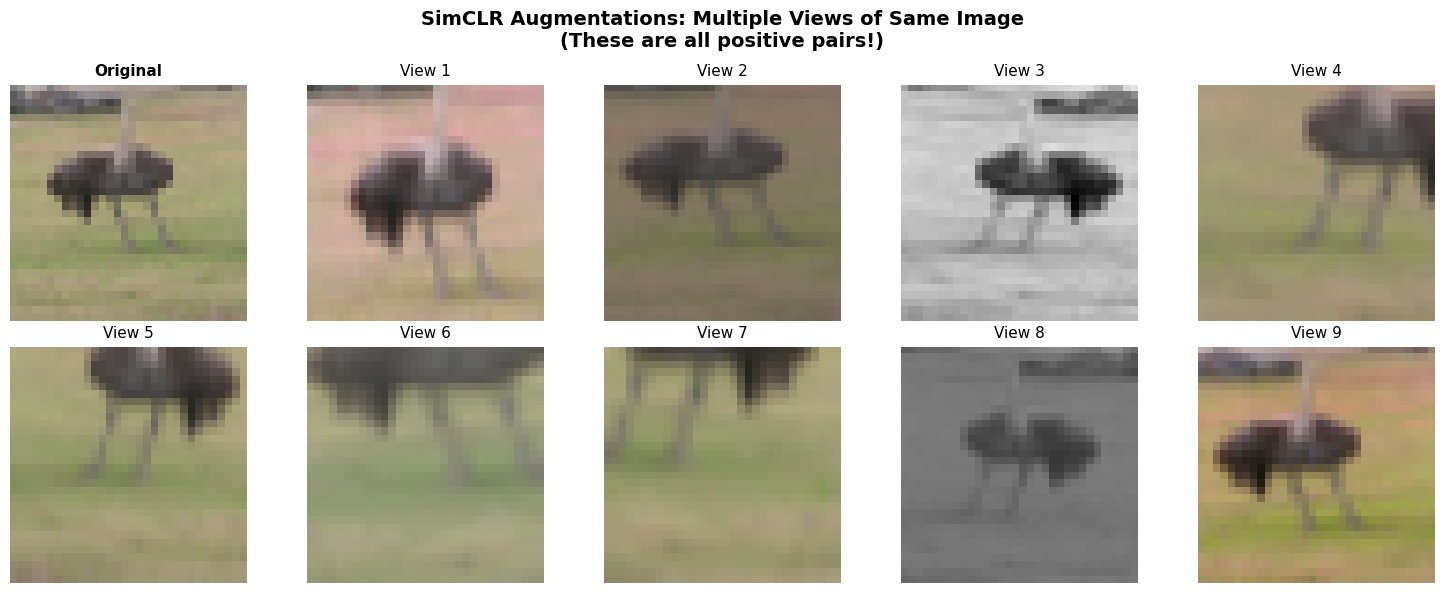

Notice how augmentations create diverse views while preserving content!
The model must learn to recognize these are all the same image.


In [12]:
# Load a sample image from CIFAR-10
temp_dataset = torchvision.datasets.CIFAR10(
    root='./data', 
    train=True, 
    download=True,
    transform=transforms.ToTensor()
)

# Get one image
original_image, _ = temp_dataset[42]  # Arbitrary choice

# Create augmentation (without normalization for visualization)
aug_viz = transforms.Compose([
    transforms.ToPILImage(),
    transforms.RandomResizedCrop(size=32, scale=(0.2, 1.0)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomApply([transforms.ColorJitter(0.4, 0.4, 0.4, 0.1)], p=0.8),
    transforms.RandomGrayscale(p=0.2),
    transforms.ToTensor(),
])

# Generate multiple views
fig, axes = plt.subplots(2, 5, figsize=(15, 6))

for row in range(2):
    for col in range(5):
        if row == 0 and col == 0:
            # Show original
            axes[row, col].imshow(original_image.permute(1, 2, 0))
            axes[row, col].set_title('Original', fontweight='bold', fontsize=11)
        else:
            # Show augmented view
            aug_img = aug_viz(original_image)
            axes[row, col].imshow(aug_img.permute(1, 2, 0))
            view_num = row * 5 + col
            axes[row, col].set_title(f'View {view_num}', fontsize=11)
        
        axes[row, col].axis('off')

plt.suptitle('SimCLR Augmentations: Multiple Views of Same Image\n(These are all positive pairs!)', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("Notice how augmentations create diverse views while preserving content!")
print("The model must learn to recognize these are all the same image.")

## 8. Creating a Contrastive Dataset

We need a dataset that returns **two augmented views** of each image.

In [13]:
class ContrastiveDataset(Dataset):
    """
    Wrapper dataset that returns two augmented views of each image.
    """
    def __init__(self, base_dataset, transform):
        self.base_dataset = base_dataset
        self.transform = transform
    
    def __len__(self):
        return len(self.base_dataset)
    
    def __getitem__(self, idx):
        # Get original image (before any transforms)
        img, label = self.base_dataset[idx]
        
        # If img is already a tensor, convert back to PIL for transforms
        if isinstance(img, torch.Tensor):
            img = transforms.ToPILImage()(img)
        
        # Generate two views
        view1 = self.transform(img)
        view2 = self.transform(img)
        
        return view1, view2, label

print("✓ ContrastiveDataset defined")
print("\nThis dataset returns (view1, view2, label) for each sample.")

✓ ContrastiveDataset defined

This dataset returns (view1, view2, label) for each sample.


## 9. SimCLR Encoder Architecture

SimCLR has two main components:

1. **Encoder** $f(\cdot)$: Extracts features from images (e.g., ResNet)
2. **Projection head** $g(\cdot)$: Maps features to embedding space where contrastive loss is computed

### Architecture:
```
Image → Encoder → Feature (h) → Projection Head → Embedding (z) → Loss
```

### Key insight:
After training, we **discard the projection head** and use the feature representation $h$ for downstream tasks!

The projection head is only used during contrastive pre-training.

### Implementing a simple encoder

We'll use a small ConvNet for CIFAR-10 (32x32 images).

In [14]:
class SimpleEncoder(nn.Module):
    """
    Simple ConvNet encoder for 32x32 images.
    """
    def __init__(self, feature_dim=128):
        super().__init__()
        
        self.encoder = nn.Sequential(
            # Input: 3 x 32 x 32
            nn.Conv2d(3, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),  # 64 x 16 x 16
            
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),  # 128 x 8 x 8
            
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),  # 256 x 4 x 4
            
            nn.AdaptiveAvgPool2d(1),  # 256 x 1 x 1
        )
        
        self.feature_dim = feature_dim
        self.fc = nn.Linear(256, feature_dim)
    
    def forward(self, x):
        h = self.encoder(x)
        h = h.view(h.size(0), -1)  # Flatten
        h = self.fc(h)
        return h

# Test the encoder
encoder = SimpleEncoder(feature_dim=128)
dummy_input = torch.randn(4, 3, 32, 32)
features = encoder(dummy_input)

print(f"Encoder output shape: {features.shape}")
print(f"Parameters: {count_parameters(encoder):,}")

Encoder output shape: torch.Size([4, 128])
Parameters: 404,608


### Implementing the projection head

The projection head is a simple MLP: usually 2-3 layers with ReLU activations.

In [15]:
class ProjectionHead(nn.Module):
    """
    MLP projection head for contrastive learning.
    """
    def __init__(self, input_dim=128, hidden_dim=128, output_dim=64):
        super().__init__()
        
        self.projection = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(inplace=True),
            nn.Linear(hidden_dim, output_dim),
        )
    
    def forward(self, x):
        return self.projection(x)

# Test
proj_head = ProjectionHead(input_dim=128, hidden_dim=128, output_dim=64)
embeddings = proj_head(features)

print(f"Projection head output shape: {embeddings.shape}")
print(f"Parameters: {count_parameters(proj_head):,}")

Projection head output shape: torch.Size([4, 64])
Parameters: 24,768


### Complete SimCLR model

In [16]:
class SimCLR(nn.Module):
    """
    SimCLR model: Encoder + Projection Head
    """
    def __init__(self, feature_dim=128, projection_dim=64):
        super().__init__()
        
        self.encoder = SimpleEncoder(feature_dim=feature_dim)
        self.projection_head = ProjectionHead(
            input_dim=feature_dim,
            hidden_dim=feature_dim,
            output_dim=projection_dim
        )
    
    def forward(self, x):
        # Get features
        h = self.encoder(x)
        
        # Project to embedding space
        z = self.projection_head(h)
        
        return h, z
    
    def get_features(self, x):
        """Get features without projection (for downstream tasks)."""
        return self.encoder(x)

# Create model
model = SimCLR(feature_dim=128, projection_dim=64).to(device)

print(f"Total parameters: {count_parameters(model):,}")
print("\n✓ SimCLR model ready!")

Total parameters: 429,376

✓ SimCLR model ready!


## 10. Preparing Data

Let's load CIFAR-10 and wrap it with our contrastive dataset.

In [ ]:
# Load base dataset (no transforms)
base_dataset = torchvision.datasets.CIFAR10(
    root='./data',
    train=True,
    download=True,
    transform=None  # We'll apply transforms in ContrastiveDataset
)

# Create contrastive dataset
augmentation = get_simclr_augmentation(size=32, s=0.5)
train_dataset = ContrastiveDataset(base_dataset, transform=augmentation)

# Create dataloader
batch_size = 128
train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=0,  # No multiprocessing (ContrastiveDataset defined in notebook)
    pin_memory=False,  # Not supported on MPS
    drop_last=True  # Important: ensures all batches have same size
)

print(f"Dataset size: {len(train_dataset):,}")
print(f"Batches per epoch: {len(train_loader):,}")
print(f"Batch size: {batch_size}")
print(f"\nEach batch provides {2 * batch_size} views ({batch_size} positive pairs)")

### Verify data loading

In [ ]:
# Get a batch
view1, view2, labels = next(iter(train_loader))

print(f"View 1 shape: {view1.shape}")
print(f"View 2 shape: {view2.shape}")
print(f"Labels shape: {labels.shape}")
print("\n(Note: Labels are not used during contrastive learning, only for evaluation!)")

/Users/tsilva/repos/tsilva/aiml-notebooks/.venv/lib/python3.12/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)
Traceback (most recent call last):
  File "<string>", line 1, in <module>
  File "/Users/tsilva/.pyenv/versions/3.12.2/lib/python3.12/multiprocessing/spawn.py", line 122, in spawn_main
    exitcode = _main(fd, parent_sentinel)
               ^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Users/tsilva/.pyenv/versions/3.12.2/lib/python3.12/multiprocessing/spawn.py", line 132, in _main
    self = reduction.pickle.load(from_parent)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
AttributeError: Can't get attribute 'ContrastiveDataset' on <module '__main__' (<class '_frozen_importlib.BuiltinImporter'>)>


## 11. Training Loop

Now let's train our SimCLR model! The training loop is straightforward:

1. Get two views of each image
2. Pass both through encoder + projection head
3. Compute InfoNCE loss
4. Backpropagate and update weights

### Setup optimizer and training

In [ ]:
# Hyperparameters
learning_rate = 3e-4
temperature = 0.5
epochs = 20  # For demo; real SimCLR trains for 100-1000 epochs

# Optimizer
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

# Learning rate scheduler (cosine decay)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer, 
    T_max=epochs * len(train_loader),
    eta_min=1e-6
)

print(f"Training configuration:")
print(f"  Learning rate: {learning_rate}")
print(f"  Temperature: {temperature}")
print(f"  Epochs: {epochs}")
print(f"  Optimizer: Adam")
print(f"  LR schedule: Cosine annealing")

### Training function

In [ ]:
def train_epoch(model, loader, optimizer, scheduler, temperature, device):
    """
    Train for one epoch.
    """
    model.train()
    total_loss = 0
    
    pbar = tqdm(loader, desc='Training')
    for view1, view2, _ in pbar:
        view1 = view1.to(device)
        view2 = view2.to(device)
        
        # Forward pass for both views
        _, z1 = model(view1)
        _, z2 = model(view2)
        
        # Compute loss
        loss = info_nce_loss(z1, z2, temperature=temperature)
        
        # Backward pass
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        scheduler.step()
        
        # Track loss
        total_loss += loss.item()
        pbar.set_postfix({'loss': f'{loss.item():.4f}'})
    
    avg_loss = total_loss / len(loader)
    return avg_loss

print("✓ Training function defined")

### Run training

In [ ]:
history = TrainingHistory()

print("Starting training...\n")

for epoch in range(epochs):
    print(f"Epoch {epoch + 1}/{epochs}")
    
    # Train
    train_loss = train_epoch(
        model, train_loader, optimizer, scheduler, temperature, device
    )
    
    # Log
    history.update(train_loss=train_loss)
    
    print(f"Train Loss: {train_loss:.4f}\n")

print("✓ Training complete!")

### Plot training curve

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(history.history['train_loss'], linewidth=2, marker='o')
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('InfoNCE Loss', fontsize=12)
plt.title('Contrastive Learning Training Progress', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Final loss: {history.history['train_loss'][-1]:.4f}")
print(f"Improvement: {(history.history['train_loss'][0] - history.history['train_loss'][-1]) / history.history['train_loss'][0] * 100:.1f}%")

## 12. Evaluating Learned Representations

How do we know if contrastive learning worked?

### Qualitative evaluation:
1. Visualize embedding space (t-SNE or PCA)
2. Check if same-class samples cluster together

### Quantitative evaluation:
1. **Linear evaluation**: Train a linear classifier on frozen features
2. **Fine-tuning**: Fine-tune entire model on downstream task

We'll do a quick linear evaluation.

### Extract features from the model

In [ ]:
@torch.no_grad()
def extract_features(model, loader, device, max_samples=2000):
    """
    Extract features for a subset of data.
    """
    model.eval()
    features_list = []
    labels_list = []
    
    samples_collected = 0
    
    for view1, _, labels in loader:
        if samples_collected >= max_samples:
            break
        
        view1 = view1.to(device)
        
        # Get features (not projections!)
        features = model.get_features(view1)
        
        features_list.append(features.cpu())
        labels_list.append(labels)
        
        samples_collected += view1.size(0)
    
    features = torch.cat(features_list, dim=0)
    labels = torch.cat(labels_list, dim=0)
    
    return features, labels

# Extract features
print("Extracting features...")
features, labels = extract_features(model, train_loader, device, max_samples=2000)
print(f"\nExtracted {features.shape[0]} samples")
print(f"Feature dimension: {features.shape[1]}")

### Visualize embeddings with t-SNE

In [ ]:
from sklearn.manifold import TSNE

# Apply t-SNE
print("Computing t-SNE (this may take a minute)...")
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
features_2d = tsne.fit_transform(features.numpy())

# Plot
plt.figure(figsize=(12, 10))
scatter = plt.scatter(
    features_2d[:, 0], 
    features_2d[:, 1], 
    c=labels.numpy(), 
    cmap='tab10',
    alpha=0.6,
    s=20
)
plt.colorbar(scatter, ticks=range(10), label='Class')
plt.xlabel('t-SNE Component 1', fontsize=12)
plt.ylabel('t-SNE Component 2', fontsize=12)
plt.title('Learned Representations (t-SNE)\nColors = CIFAR-10 Classes', 
          fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\nLook for clusters! If contrastive learning worked:")
print("• Same-class samples should cluster together")
print("• Different classes should be separated")
print("\nRemember: The model never saw class labels during training!")

## 13. Experiments: Temperature Sensitivity

Let's verify that temperature is indeed important by comparing different values.

In [ ]:
# Get a batch for testing
view1_test, view2_test, _ = next(iter(train_loader))
view1_test = view1_test.to(device)
view2_test = view2_test.to(device)

# Compute embeddings
model.eval()
with torch.no_grad():
    _, z1_test = model(view1_test)
    _, z2_test = model(view2_test)

# Test different temperatures
temperatures_test = [0.05, 0.1, 0.3, 0.5, 0.7, 1.0]
losses_by_temp = []

for tau in temperatures_test:
    loss = info_nce_loss(z1_test, z2_test, temperature=tau)
    losses_by_temp.append(loss.item())

# Plot
plt.figure(figsize=(10, 6))
plt.plot(temperatures_test, losses_by_temp, marker='o', linewidth=2, markersize=10)
plt.xlabel('Temperature (τ)', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.title('Loss vs Temperature (After Training)', fontsize=14, fontweight='bold')
plt.axvline(x=temperature, color='red', linestyle='--', 
            label=f'Training τ = {temperature}', linewidth=2)
plt.grid(True, alpha=0.3)
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()

print(f"Optimal temperature (lowest loss): τ = {temperatures_test[np.argmin(losses_by_temp)]}")
print(f"Training temperature: τ = {temperature}")

## 14. Understanding What Was Learned

Let's visualize what the model considers similar.

### Find nearest neighbors in embedding space

In [ ]:
@torch.no_grad()
def find_nearest_neighbors(model, query_img, dataset, k=5, device=device):
    """
    Find k nearest neighbors to query image in embedding space.
    """
    model.eval()
    
    # Get query embedding
    query_img = query_img.unsqueeze(0).to(device)
    query_features = model.get_features(query_img)
    query_features = F.normalize(query_features, dim=1)
    
    # Sample candidate images
    n_candidates = min(500, len(dataset))
    indices = torch.randperm(len(dataset))[:n_candidates]
    
    # Get candidate embeddings
    candidate_features = []
    for idx in indices:
        img, _, _ = dataset[int(idx)]
        img = img.unsqueeze(0).to(device)
        feat = model.get_features(img)
        candidate_features.append(feat)
    
    candidate_features = torch.cat(candidate_features, dim=0)
    candidate_features = F.normalize(candidate_features, dim=1)
    
    # Compute similarities
    similarities = torch.mm(query_features, candidate_features.t()).squeeze(0)
    
    # Get top k
    top_k_sims, top_k_indices = torch.topk(similarities, k)
    
    # Map back to dataset indices
    top_k_dataset_indices = indices[top_k_indices.cpu()]
    
    return top_k_dataset_indices, top_k_sims.cpu()

print("✓ Nearest neighbor function defined")

### Visualize nearest neighbors for sample images

In [ ]:
# Get a random query image
query_idx = np.random.randint(len(train_dataset))
query_img, _, query_label = train_dataset[query_idx]

# Find neighbors
neighbor_indices, similarities = find_nearest_neighbors(
    model, query_img, train_dataset, k=6, device=device
)

# Visualize
fig, axes = plt.subplots(1, 7, figsize=(18, 3))

# Show query
query_img_viz = query_img.cpu().permute(1, 2, 0)
query_img_viz = query_img_viz * torch.tensor(CIFAR10_STD).view(1, 1, 3) + torch.tensor(CIFAR10_MEAN).view(1, 1, 3)
query_img_viz = torch.clamp(query_img_viz, 0, 1)
axes[0].imshow(query_img_viz)
axes[0].set_title('Query', fontweight='bold', fontsize=12)
axes[0].axis('off')
axes[0].add_patch(plt.Rectangle((0, 0), 31, 31, fill=False, edgecolor='red', linewidth=3))

# Show neighbors
for i, (idx, sim) in enumerate(zip(neighbor_indices, similarities)):
    img, _, label = train_dataset[int(idx)]
    img_viz = img.cpu().permute(1, 2, 0)
    img_viz = img_viz * torch.tensor(CIFAR10_STD).view(1, 1, 3) + torch.tensor(CIFAR10_MEAN).view(1, 1, 3)
    img_viz = torch.clamp(img_viz, 0, 1)
    
    axes[i + 1].imshow(img_viz)
    axes[i + 1].set_title(f'Sim: {sim:.3f}', fontsize=11)
    axes[i + 1].axis('off')

plt.suptitle('Nearest Neighbors in Embedding Space\n(Red border = query image)', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("The model learned to group visually similar images together!")
print("(Try running this cell multiple times to see different queries)")

## 15. Key Takeaways

### What we learned:

1. **Contrastive learning** learns representations by contrasting positive and negative pairs
   - Positive pairs: augmented views of the same image
   - Negative pairs: views from different images

2. **InfoNCE loss** is the key:
   - Pull positives together in embedding space
   - Push negatives apart
   - Essentially a classification problem: identify the positive among negatives

3. **Temperature** $\tau$ controls task difficulty:
   - Low: harder task, sharper distributions
   - High: easier task, softer distributions
   - Sweet spot: typically 0.1-0.5

4. **Data augmentation** is critical:
   - Need to create meaningful positive pairs
   - SimCLR: crop + color jitter are most important
   - Augmentations define what features are "invariant"

5. **Architecture**: Encoder + Projection Head
   - Encoder extracts features
   - Projection head used only during training
   - Use encoder features for downstream tasks

### Why it matters:

- **Self-supervised**: No labels needed for pre-training!
- **Powerful**: SimCLR matches supervised learning with 1% of labels
- **General**: Works across domains (vision, language, audio)
- **Foundation**: Powers models like CLIP, MoCo, SwAV

### Real-world applications:

- **SimCLR**: Self-supervised vision pre-training
- **MoCo**: Momentum-based contrastive learning
- **CLIP**: Vision-language contrastive learning (powers DALL-E, Stable Diffusion)
- **SimCSE**: Contrastive learning for sentence embeddings

### Next steps:

1. Train for more epochs (100+) with larger batch sizes (256-1024)
2. Try different encoder architectures (ResNet-50, Vision Transformer)
3. Experiment with different augmentations
4. Evaluate on downstream tasks (linear evaluation, fine-tuning)
5. Explore variants: MoCo, BYOL, SwAV

**Contrastive learning is a paradigm shift**: learning from data structure, not labels!